In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
x = np.arange(20)
y = 1 + x**2

In [5]:
y

array([  1,   2,   5,  10,  17,  26,  37,  50,  65,  82, 101, 122, 145,
       170, 197, 226, 257, 290, 325, 362])

In [6]:
X = x.reshape(-1,1)
X

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19]])

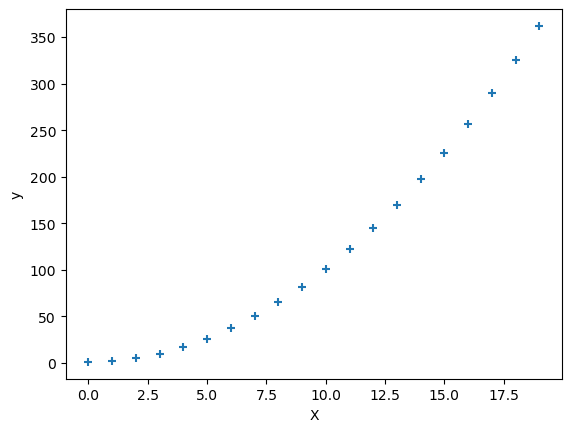

In [7]:
plt.xlabel('X')
plt.ylabel('y')
plt.scatter(X, y, marker='+')

In [46]:
class MultiLinearRegression:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.alpha = learning_rate
        self.epochs = epochs

    def compute_gradient(self, X, y):
        dw = np.zeros(self.n)
        db = 0.0

        for i in range(self.m):
            f_x = np.dot(self.w, X[i]) + self.b
            error = f_x - y[i]
            for j in range(self.n):
                dw[j] += error*X[i][j]
            db += error
        dw = dw/self.m
        db = db/self.m
        return dw, db

    def cost_function(self):
        cost = 0.0

        for i in range(self.m):
            f_x = np.dot(self.w, X[i]) + self.b
            error = f_x - y[i]
            cost += error**2
        cost = cost/(2*self.m)
        return cost
    
    def fit(self, X, y):
        # Number of samples, number of features
        self.m, self.n = X.shape

        self.w = np.zeros(self.n)
        self.b = 0

        for epoch in range(self.epochs):
            # Calculate the gradient and update the parameters
            dw, db = self.compute_gradient(X, y)

            # Update parameters
            self.w = self.w - self.alpha*dw
            self.b = self.b - self.alpha*db

            cost = self.cost_function()
            if epoch%100 == 0:
                print(f'Epochs {epoch}; Cost:{cost:.2f}')

    def predict(self, X):
        return np.dot(X, self.w) + self.b
                

In [47]:
model = MultiLinearRegression(learning_rate=0.001, epochs=10000)
model.fit(X, y)

Epochs 0; Cost:11088.20
Epochs 100; Cost:855.07
Epochs 200; Cost:833.38
Epochs 300; Cost:812.81
Epochs 400; Cost:793.32
Epochs 500; Cost:774.85
Epochs 600; Cost:757.34
Epochs 700; Cost:740.74
Epochs 800; Cost:725.00
Epochs 900; Cost:710.09
Epochs 1000; Cost:695.95
Epochs 1100; Cost:682.55
Epochs 1200; Cost:669.85
Epochs 1300; Cost:657.81
Epochs 1400; Cost:646.40
Epochs 1500; Cost:635.58
Epochs 1600; Cost:625.33
Epochs 1700; Cost:615.61
Epochs 1800; Cost:606.40
Epochs 1900; Cost:597.67
Epochs 2000; Cost:589.39
Epochs 2100; Cost:581.55
Epochs 2200; Cost:574.11
Epochs 2300; Cost:567.06
Epochs 2400; Cost:560.38
Epochs 2500; Cost:554.05
Epochs 2600; Cost:548.05
Epochs 2700; Cost:542.36
Epochs 2800; Cost:536.96
Epochs 2900; Cost:531.85
Epochs 3000; Cost:527.01
Epochs 3100; Cost:522.41
Epochs 3200; Cost:518.06
Epochs 3300; Cost:513.93
Epochs 3400; Cost:510.02
Epochs 3500; Cost:506.32
Epochs 3600; Cost:502.80
Epochs 3700; Cost:499.47
Epochs 3800; Cost:496.31
Epochs 3900; Cost:493.32
Epochs 400

In [48]:
y_pred = model.predict(X)
y_pred

array([-52.07073989, -33.37364711, -14.67655434,   4.02053844,
        22.71763122,  41.41472399,  60.11181677,  78.80890954,
        97.50600232, 116.20309509, 134.90018787, 153.59728064,
       172.29437342, 190.99146619, 209.68855897, 228.38565174,
       247.08274452, 265.77983729, 284.47693007, 303.17402284])

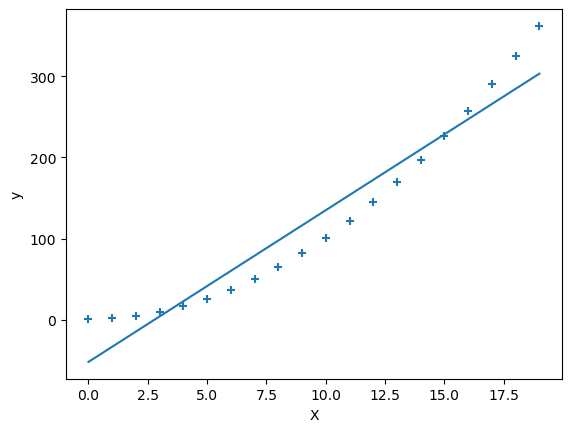

In [49]:
plt.xlabel('X')
plt.ylabel('y')
plt.scatter(X, y, marker='+')
plt.plot(X, y_pred)